#### run this command as needed to re-establish connection to Big Query
gcloud auth login --update-adc

### Set up and getting data

In [1]:
import pandas as pd
import numpy as np
import time
from google.cloud import bigquery
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
import matplotlib.pyplot as plt
import random
import torch
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

client = bigquery.Client()

In [2]:
def lift_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    expected_positives = y_true.sum() * 0.01
    lift = actual_positives / expected_positives if expected_positives != 0 else 0
    return lift

def true_positives_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    return actual_positives

def num_samples_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    return top_1_percent

def f1_score_top_1_percent(y_true, y_pred_proba):
    top_1_percent = int(0.01 * len(y_true))
    top_indices = np.argsort(y_pred_proba)[-top_1_percent:]
    y_true_top = y_true.iloc[top_indices]
    y_pred_top = np.ones(top_1_percent)
    return f1_score(y_true_top, y_pred_top)


# Make scorers
scorers = {
    'lift@1%': make_scorer(lift_at_1_percent, needs_proba=True),
    'f1@1%': make_scorer(f1_score_top_1_percent, needs_proba=True),
    'true_positives@1%': make_scorer(true_positives_at_1_percent, needs_proba=True),
    'num_samples@1%': make_scorer(num_samples_at_1_percent, needs_proba=True),
    'AUC':'roc_auc',
    'weighted AUC':make_scorer(roc_auc_score, needs_proba = True, multi_class = 'ovr', average = 'weighted') 
}

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [3]:
# Get labels (acute IP) stay (0=no, 1=yes) in the 6 months post-index date
sql = """
SELECT
    *
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_outcome_ip_cases_w_drg` AS o
WHERE 1=1 
  AND o.asdb_member_key IN (SELECT asdb_member_key FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_non_embedding_features` WHERE 1=1 AND NOT asdb_plan_key IN (33, 54) AND post_mnths >= 6)"""
outcome_detail = client.query(sql).to_dataframe() 
outcome_detail.shape

(74094, 13)

In [4]:
outcome_detail.head()

,asdb_member_key,asdb_event_start_dt,asdb_event_end_dt,final_discharge_dt,prindiag,admit_drg,drg_type,ip_type,calc_los,event_ct,admit_los,paid_los,ip_paid_amt
0,480569879,2024-02-14 00:00:00+00:00,2024-02-14 00:00:00+00:00,2024-02-14 00:00:00+00:00,F14.20,None,None,Non-Acute,0,1.0,0,1,196.880000000
1,480569879,2024-01-30 00:00:00+00:00,2024-01-30 00:00:00+00:00,2024-01-30 00:00:00+00:00,F14.20,None,None,Non-Acute,0,1.0,0,1,196.880000000
2,351902065,2023-11-17 00:00:00+00:00,2023-11-17 00:00:00+00:00,2023-11-17 00:00:00+00:00,F31.9,None,None,Non-Acute,0,1.0,0,1,382.970000000
3,480569879,2024-01-31 00:00:00+00:00,2024-01-31 00:00:00+00:00,2024-01-31 00:00:00+00:00,F14.20,None,None,Non-Acute,0,1.0,0,1,196.880000000
4,480569879,2024-02-07 00:00:00+00:00,2024-02-07 00:00:00+00:00,2024-02-07 00:00:00+00:00,F14.20,None,None,Non-Acute,0,1.0,0,1,196.880000000


In [5]:
outcome_detail['drg_type'].value_counts()

drg_type
Mental Health                   21572
Impactable                      20362
Non-Impactable                  16722
Pregnancy/Childbirth/Newborn    14236
Trauma                            447
Transplant                         52
Name: count, dtype: int64

In [6]:
impactable   = np.unique(outcome_detail.loc[outcome_detail['drg_type'] == 'Impactable', 'asdb_member_key'])
unimpactable = np.unique(outcome_detail.loc[outcome_detail['drg_type'] == 'Non-Impactable', 'asdb_member_key'])
bh           = np.unique(outcome_detail.loc[outcome_detail['drg_type'] == 'Mental Health', 'asdb_member_key'])
pregnancy    = np.unique(outcome_detail.loc[outcome_detail['drg_type'] == 'Pregnancy/Childbirth/Newborn', 'asdb_member_key'])

In [7]:
merged = pd.read_feather("OOT.feather")  

In [8]:
merged.head()

,sum_ed_visits_yr1,ed_flag_yr1,sum_avoidable_yr1,sum_unnecessary_yr1,sum_preventable_yr1,low_sev_ed_visits_yr1,low_med_sev_ed_visits_yr1,med_sev_ed_visits_yr1,med_high_sev_ed_visits_yr1,high_sev_ed_visits_yr1,...,ethnicity_code_ETHN0021,ethnicity_code_ETHN0023,ethnicity_code_ETHN0025,ethnicity_code_ETHN0029,primarylanguage_desc_ARABIC,primarylanguage_desc_ENGLISH,primarylanguage_desc_No Language,primarylanguage_desc_SPANISH,primarylanguage_desc_UNKNOWN,acute_ip_flag
asdb_member_key,,,,,,,,,,,,,,,,,,,,,
450722972,1,1,0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
451333181,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
520490691,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
72031025,2,1,0,0,0,0,0,0,2,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
351519251,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


In [9]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("\nTest Set:")
check_label_distribution(merged.loc[:, 'acute_ip_flag'])


Test Set:
1609769 26416 0.016409807866843006


(1609769, 26416, 0.016409807866843006)

In [10]:
merged['impactable']   = np.where(merged.index.isin(impactable), 1, 0)
merged['unimpactable'] = np.where(merged.index.isin(unimpactable), 1, 0)
merged['bh']           = np.where(merged.index.isin(bh), 1, 0)
merged['pregnancy']     = np.where(merged.index.isin(pregnancy), 1, 0)

In [11]:
merged['impactable'].value_counts()

impactable
0    1619341
1      16844
Name: count, dtype: int64

In [12]:
merged['unimpactable'].value_counts()

unimpactable
0    1621953
1      14232
Name: count, dtype: int64

In [13]:
merged['bh'].value_counts()

bh
0    1621941
1      14244
Name: count, dtype: int64

In [14]:
merged['pregnancy'].value_counts()

pregnancy
0    1622039
1      14146
Name: count, dtype: int64

In [15]:
pd.crosstab(merged['acute_ip_flag'], merged['impactable'], dropna=False)

impactable,0,1
acute_ip_flag,,
0,1609266,503
1,10075,16341


In [16]:
pd.crosstab(merged['acute_ip_flag'], merged['unimpactable'], dropna=False)

unimpactable,0,1
acute_ip_flag,,
0,1607077,2692
1,14876,11540


In [17]:
pd.crosstab(merged['acute_ip_flag'], merged['bh'], dropna=False)

bh,0,1
acute_ip_flag,,
0,1596684,13085
1,25257,1159


In [18]:
pd.crosstab(merged['acute_ip_flag'], merged['pregnancy'], dropna=False)

pregnancy,0,1
acute_ip_flag,,
0,1595697,14072
1,26342,74


In [19]:
pd.crosstab(merged['pregnancy'], merged['impactable'], dropna=False)

impactable,0,1
pregnancy,,
0,1605224,16815
1,14117,29


In [20]:
import xgboost as xgb
model = xgb.XGBClassifier()
model.load_model("xgboost_model_elle_check.cbm")

In [21]:
model

XGBClassifier(base_score='1.3198793E-1', booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None,
              feature_types=['int', 'int', 'int', 'float', 'int', 'int', 'int',
                             'int', 'int', 'int', 'int', 'int', 'int', 'int',
                             'int', 'int', 'int', 'int', 'int'...
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [22]:
import pandas as pd
# Get the selected features from RFE

f = open('xgboost_selected_features.txt', 'r')
selected_features = [x.strip() for x in f.readlines()]
print(len(selected_features))
f.close()

merged = merged[merged['acute_ip_flag'].notna()]

X_test_df = pd.DataFrame(merged, columns = merged.columns)
X_test = X_test_df[selected_features]

y_test = merged['acute_ip_flag']

# X_test

78


#### Metrics for Optimal Model

In [23]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8740679337466811
1% Lift:  22.70215021199273
1% PPV:  36.65423873846342
1% Sensitivity:  22.70215021199273
10% Lift:  6.5119624470018165
10% PPV:  10.51351318314611
10% Sensitivity:  65.11962447001817


Text(0.5, 427.9555555555555, 'Predicted label')

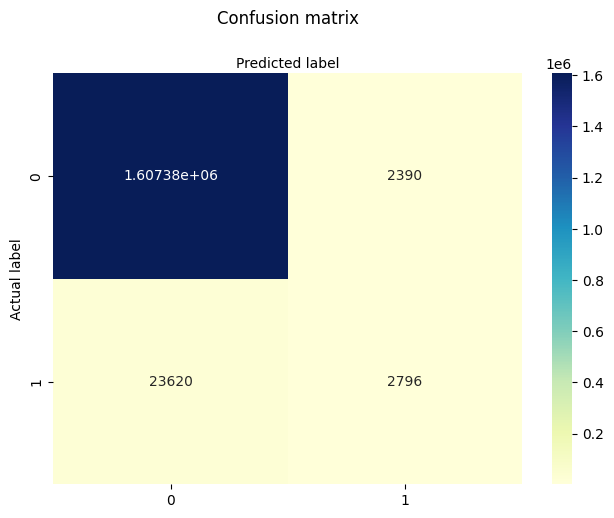

In [24]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_test_class = model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [25]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_pred_test_class, target_names=target_names))
#10.6% Recall/sensitivity; 53.9% PPV

              precision    recall  f1-score   support

  without IP       0.99      1.00      0.99   1609769
     with IP       0.54      0.11      0.18     26416

    accuracy                           0.98   1636185
   macro avg       0.76      0.55      0.58   1636185
weighted avg       0.98      0.98      0.98   1636185



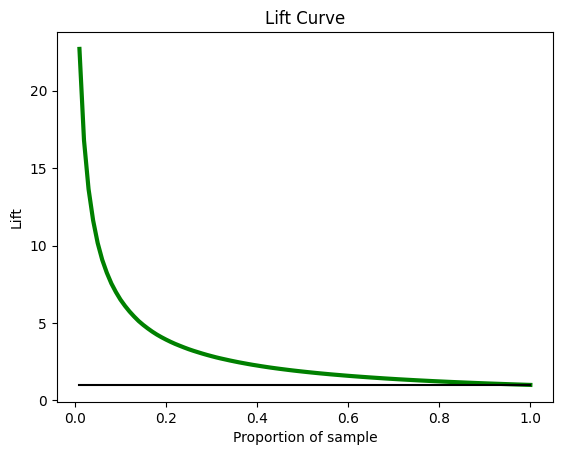

In [26]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
y_pred_test = model.predict_proba(X_test)[:, 1]
plot_lift_curve(y_test, y_pred_test, step=0.01)


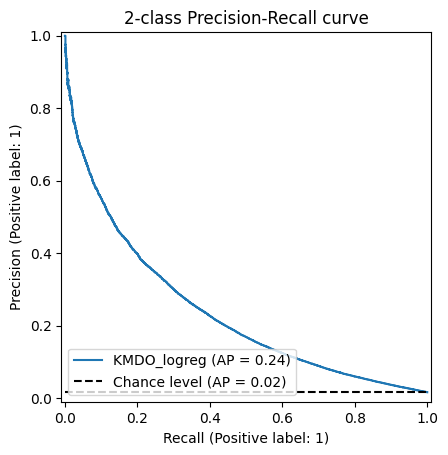

In [27]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [28]:
from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_test)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.23664508546850083


#impactable subset

In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = merged['impactable'].reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(merged['impactable'], y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8833045544914168
1% Lift:  24.33507480408454
1% PPV:  25.05348083857955
1% Sensitivity:  24.33507480408454
10% Lift:  6.680717169318451
10% PPV:  6.877605153467223
10% Sensitivity:  66.80717169318451


Text(0.5, 427.9555555555555, 'Predicted label')

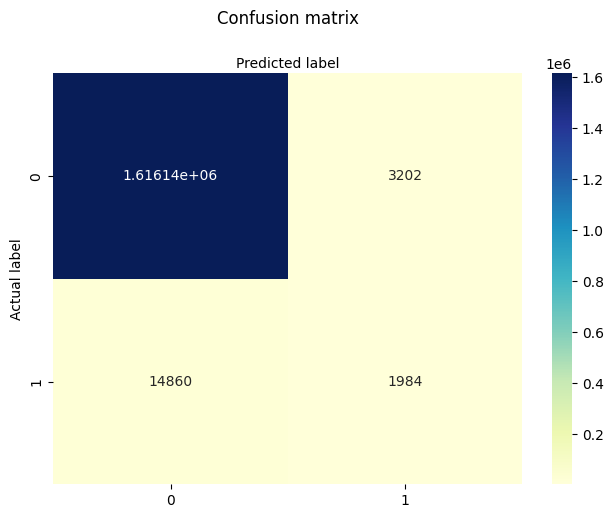

In [30]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_test_class = model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(merged['impactable'], y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
#11.8% Recall/Sensitivity; 38.3% PPV

In [36]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(merged['impactable'], y_pred_test_class, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.99      1.00      0.99   1619341
     with IP       0.38      0.12      0.18     16844

    accuracy                           0.99   1636185
   macro avg       0.69      0.56      0.59   1636185
weighted avg       0.98      0.99      0.99   1636185



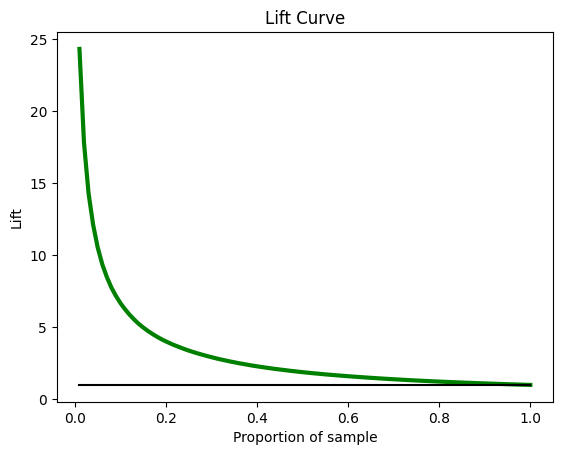

In [32]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
y_pred_test = model.predict_proba(X_test)[:, 1]
plot_lift_curve(merged['impactable'], y_pred_test, step=0.01)

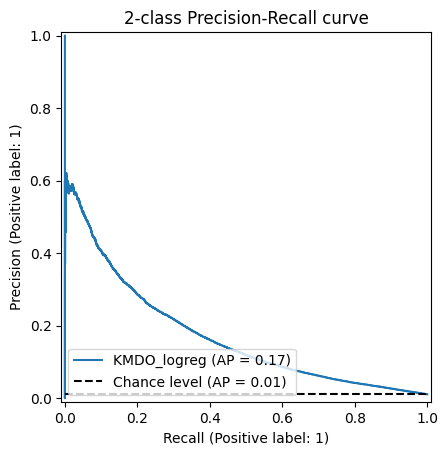

In [33]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    model, X_test, merged['impactable'], name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [34]:
from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

precision, recall, thresholds = precision_recall_curve(merged['impactable'], y_pred_test)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.17020982021766679


In [37]:
### PASTED OVER FROM GITHUB
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df
lift_chart= lift_chart(X_test, merged['impactable'], model)
lift_chart

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.982933,0.305562,4099,16362,1.000009,24.335075,24.335075,1.000009,24.334852
1,0.305551,0.199550,1900,16362,1.000009,11.279981,35.615056,2.000018,17.807365
2,0.199548,0.149245,1229,16362,1.000009,7.296367,42.911422,3.000028,14.303676
3,0.149243,0.118627,945,16362,1.000009,5.610306,48.521729,4.000037,12.130321
4,0.118622,0.098242,719,16362,1.000009,4.268582,52.790311,5.000046,10.557965
...,...,...,...,...,...,...,...,...,...
95,0.002247,0.002161,6,16362,1.000009,0.035621,99.780337,95.999963,1.039379
96,0.002161,0.002064,11,16362,1.000009,0.065305,99.845642,96.999972,1.029337
97,0.002064,0.001937,7,16362,1.000009,0.041558,99.887200,97.999982,1.019257
98,0.001937,0.001735,8,16362,1.000009,0.047495,99.934695,98.999991,1.009441


In [40]:
lift_chart.to_csv('impactable_lift_chart_xgboost.csv')

In [26]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()

In [23]:
merged['y_pred'] = model.predict(X_test)

In [24]:
merged['y_prob'] = model.predict_proba(X_test)[:, 1]

In [25]:
threshold = 0.3

merged['y_predict_class'] = ((model.predict_proba(X_test)[:, 1])>= threshold).astype(int)

In [26]:
y_pred = merged[['y_pred', 'y_prob', 'y_predict_class', 'impactable']]
y_pred

y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['impactable'], y_pred['y_predict_class'])

y_predict_class,0,1
impactable,,
0,1606612,12729
1,12654,4190


In [27]:
y_pred.head()

,y_pred,y_prob,y_predict_class,impactable
asdb_member_key,,,,
450722972,0,0.006325,0,0
451333181,0,0.009149,0,0
520490691,0,0.012231,0,0
72031025,0,0.011996,0,0
351519251,0,0.031738,0,0


In [28]:
m0_3 = merged.loc[merged['tenure_yr1'].isin([0,1,2,3,])]
m4_8 = merged.loc[merged['tenure_yr1'].isin([4,5,6,7,8,])]
m_9_13 = merged.loc[merged['tenure_yr1'].isin([9,10,11,12,13,])]

In [29]:
Foster = merged[merged['coa_population_category_Foster'] == 1]

ABD = merged[(merged['coa_population_category_DD'] == 1) | 
             (merged['coa_population_category_ABD Non Dual Non LTSS'] == 1)]

LTSS = merged[(merged['coa_population_category_ABD Non Dual LTSS'] == 1) | 
              (merged['coa_population_category_Dual Elig LTSS'] == 1) |
              (merged['coa_population_category_Dual Int LTSS'] == 1) |
              (merged['coa_population_category_LTSS Only'] == 1) ]

Dual = merged[(merged['coa_population_category_Dual Elig NonLTSS'] == 1) | 
             (merged['coa_population_category_Dual Int NonLTSS'] == 1)]

BH = merged[(merged['coa_population_category_BH Int SMI'] == 1)]

Adult = merged[(merged['coa_population_category_Expansion'] == 1) | 
             ((merged['coa_population_category_TANF'] == 1) & (merged['agenbr'] >= 18)) |
             ((merged['coa_population_category_CHIP'] == 1) & (merged['agenbr'] >= 18))]

Kid = merged[((merged['coa_population_category_TANF'] == 1) & (merged['agenbr'] < 18)) | 
             ((merged['coa_population_category_CHIP'] == 1) & (merged['agenbr'] < 18)) ]

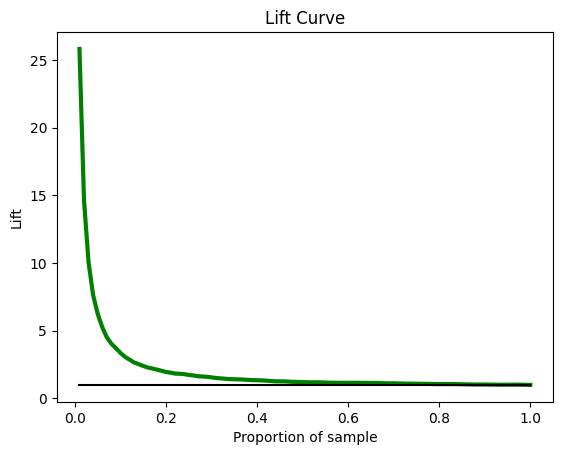

In [28]:
plot_lift_curve(Foster['impactable'], Foster['y_predict_class'], step=0.01)

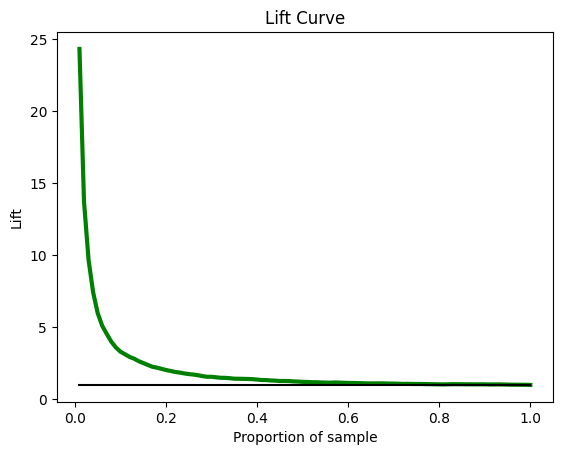

In [29]:
plot_lift_curve(LTSS['impactable'], LTSS['y_predict_class'], step=0.01)

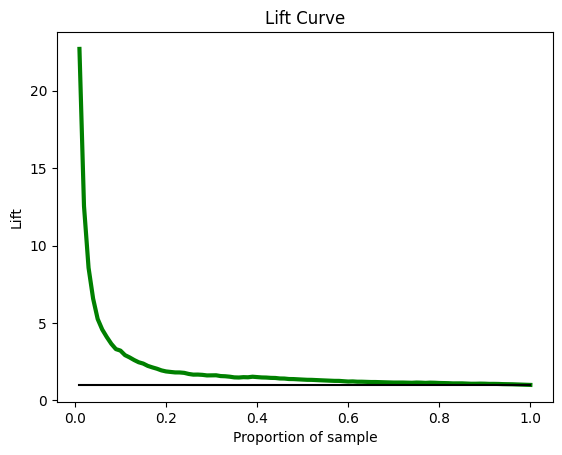

In [30]:
plot_lift_curve(Dual['impactable'], Dual['y_predict_class'], step=0.01)

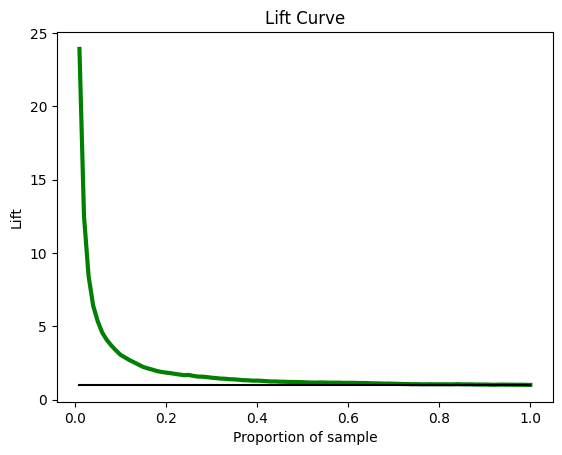

In [31]:
plot_lift_curve(BH['impactable'], BH['y_predict_class'], step=0.01)

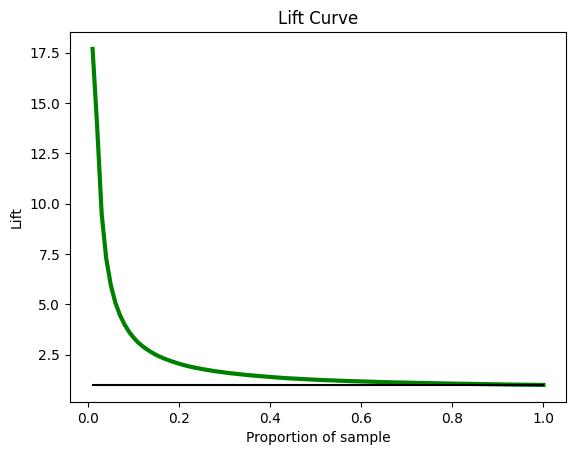

In [32]:
plot_lift_curve(Adult['impactable'], Adult['y_predict_class'], step=0.01)

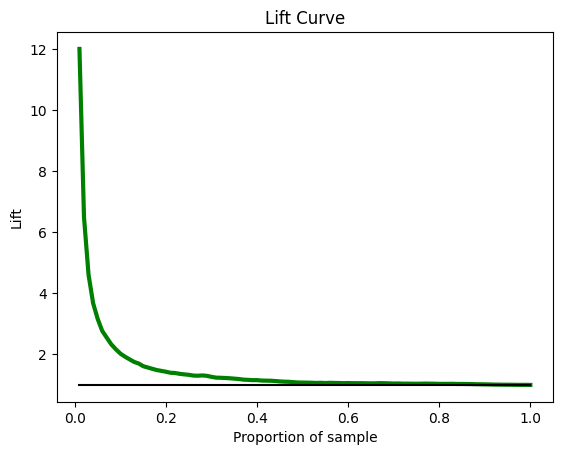

In [33]:
plot_lift_curve(Kid['impactable'], Kid['y_predict_class'], step=0.01)

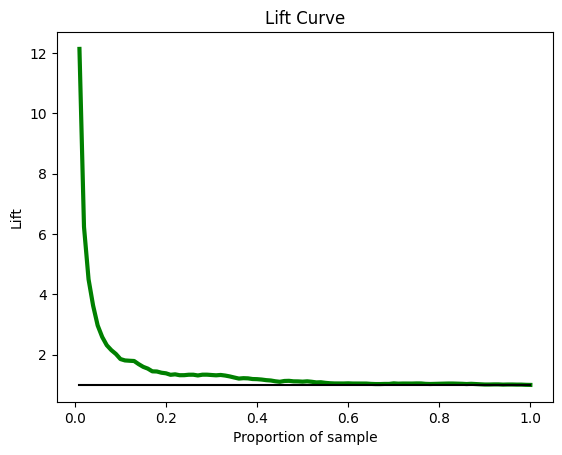

In [34]:
plot_lift_curve(m0_3['impactable'], m0_3['y_predict_class'], step=0.01)

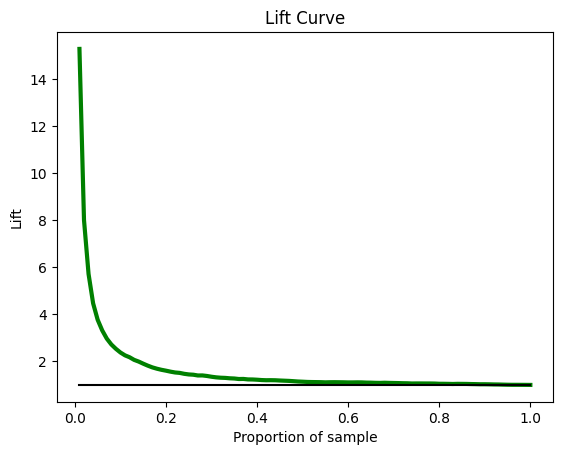

In [35]:
plot_lift_curve(m4_8['impactable'], m4_8['y_predict_class'], step=0.01)

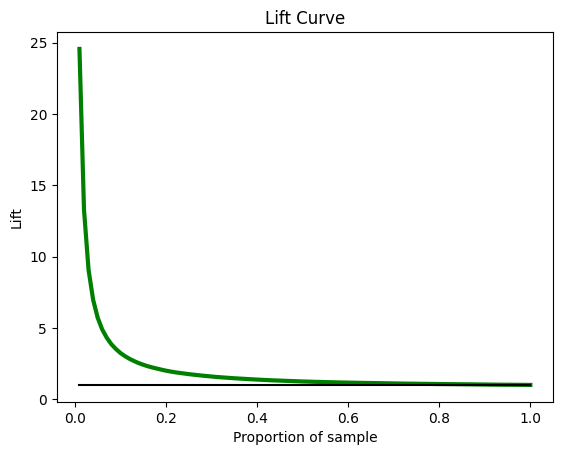

In [36]:
plot_lift_curve(m_9_13['impactable'], m_9_13['y_predict_class'], step=0.01)

In [30]:
def lift_chart(df):
    avg_tgt = df['impactable']/len(df['impactable'])
    df_data = df.copy()
    df_data['Actual'] = df['impactable']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['impactable']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df   

In [44]:
#lift_chart(merged[merged['tenure_yr1'].isin([0,1,2,3])])
lift_chart(m0_3)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.828634,0.049761,151,2556,10.003522,51.013514,51.013514,10.003522,5.099555
1,0.049701,0.029076,47,2555,9.999609,15.878378,66.891892,20.003131,3.344071
2,0.029076,0.020524,42,2555,9.999609,14.189189,81.081081,30.002740,2.702456
3,0.020512,0.013586,23,2555,9.999609,7.770270,88.851351,40.002348,2.221153
4,0.013586,0.009091,8,2555,9.999609,2.702703,91.554054,50.001957,1.831009
5,0.009091,0.006597,5,2555,9.999609,1.689189,93.243243,60.001565,1.554014
6,0.006597,0.005077,8,2555,9.999609,2.702703,95.945946,70.001174,1.370633
7,0.005077,0.004198,4,2555,9.999609,1.351351,97.297297,80.000783,1.216204
8,0.004197,0.003670,3,2555,9.999609,1.013514,98.310811,90.000391,1.092338
9,0.003670,0.001301,5,2555,9.999609,1.689189,100.000000,100.000000,1.000000


In [45]:
#lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])
lift_chart(m4_8)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.937012,0.053027,678,11345,10.000529,54.810024,54.810024,10.000529,5.480713
1,0.053020,0.028593,203,11344,9.999647,16.410671,71.220695,20.000176,3.561003
2,0.028591,0.019869,125,11344,9.999647,10.105093,81.325788,29.999824,2.710876
3,0.019869,0.014537,83,11345,10.000529,6.709782,88.035570,40.000353,2.200870
4,0.014537,0.010420,58,11344,9.999647,4.688763,92.724333,50.000000,1.854487
5,0.010419,0.007507,30,11344,9.999647,2.425222,95.149555,59.999647,1.585835
6,0.007507,0.005628,21,11345,10.000529,1.697656,96.847211,70.000176,1.383528
7,0.005628,0.004295,19,11344,9.999647,1.535974,98.383185,79.999824,1.229793
8,0.004295,0.003404,11,11344,9.999647,0.889248,99.272433,89.999471,1.103034
9,0.003404,0.000935,9,11345,10.000529,0.727567,100.000000,100.000000,1.000000


In [31]:
#lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])
lift_chart(m_9_13)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.982933,0.050355,10425,149718,10.0,68.106095,68.106095,10.0,6.810610
1,0.050355,0.022774,2016,149718,10.0,13.170445,81.276540,20.0,4.063827
2,0.022773,0.013640,1050,149718,10.0,6.859607,88.136147,30.0,2.937872
3,0.013640,0.009205,570,149718,10.0,3.723787,91.859933,40.0,2.296498
4,0.009205,0.006663,393,149718,10.0,2.567453,94.427386,50.0,1.888548
5,0.006663,0.005098,300,149718,10.0,1.959888,96.387274,60.0,1.606455
6,0.005098,0.004026,190,149718,10.0,1.241262,97.628536,70.0,1.394693
7,0.004026,0.003216,142,149718,10.0,0.927680,98.556216,80.0,1.231953
8,0.003216,0.002569,132,149718,10.0,0.862351,99.418567,90.0,1.104651
9,0.002569,0.000541,89,149718,10.0,0.581433,100.000000,100.0,1.000000


In [32]:
lift_chart(Foster)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.963765,0.050481,385,5378,10.001116,70.000000,70.000000,10.001116,6.999219
1,0.050476,0.023451,69,5377,9.999256,12.545455,82.545455,20.000372,4.127196
2,0.023449,0.014312,26,5377,9.999256,4.727273,87.272727,29.999628,2.909127
3,0.014312,0.009654,22,5378,10.001116,4.000000,91.272727,40.000744,2.281776
4,0.009654,0.006902,13,5377,9.999256,2.363636,93.636364,50.000000,1.872727
5,0.006901,0.005250,14,5377,9.999256,2.545455,96.181818,59.999256,1.603050
6,0.005249,0.004101,8,5378,10.001116,1.454545,97.636364,70.000372,1.394798
7,0.004100,0.003283,5,5377,9.999256,0.909091,98.545455,79.999628,1.231824
8,0.003283,0.002619,5,5377,9.999256,0.909091,99.454545,89.998884,1.105064
9,0.002619,0.000695,3,5378,10.001116,0.545455,100.000000,100.000000,1.000000


In [33]:
lift_chart(ABD)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.981040,0.050072,806,12009,10.000250,66.611570,66.611570,10.000250,6.660991
1,0.050071,0.023346,167,12009,10.000250,13.801653,80.413223,20.000500,4.020561
2,0.023344,0.014230,87,12008,9.999417,7.190083,87.603306,29.999917,2.920118
3,0.014230,0.009576,51,12009,10.000250,4.214876,91.818182,40.000167,2.295445
4,0.009576,0.006876,32,12009,10.000250,2.644628,94.462810,50.000416,1.889240
5,0.006876,0.005255,32,12008,9.999417,2.644628,97.107438,59.999833,1.618462
6,0.005255,0.004125,8,12009,10.000250,0.661157,97.768595,70.000083,1.396693
7,0.004125,0.003290,11,12008,9.999417,0.909091,98.677686,79.999500,1.233479
8,0.003290,0.002623,11,12009,10.000250,0.909091,99.586777,89.999750,1.106523
9,0.002623,0.000655,5,12009,10.000250,0.413223,100.000000,100.000000,1.000000


In [34]:
lift_chart(LTSS)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.970873,0.052292,308,4153,10.001686,68.903803,68.903803,10.001686,6.889219
1,0.052276,0.024169,61,4152,9.999278,13.646532,82.550336,20.000963,4.127318
2,0.024165,0.014411,32,4152,9.999278,7.158837,89.709172,30.000241,2.990282
3,0.014410,0.009593,14,4152,9.999278,3.131991,92.841163,39.999518,2.321057
4,0.009593,0.006884,11,4153,10.001686,2.460850,95.302013,50.001204,1.905994
5,0.006884,0.005220,6,4152,9.999278,1.342282,96.644295,60.000482,1.610725
6,0.005220,0.004115,6,4152,9.999278,1.342282,97.986577,69.999759,1.399813
7,0.004115,0.003314,3,4152,9.999278,0.671141,98.657718,79.999037,1.233236
8,0.003314,0.002646,2,4152,9.999278,0.447427,99.105145,89.998314,1.101189
9,0.002646,0.000746,4,4153,10.001686,0.894855,100.000000,100.000000,1.000000


In [35]:
lift_chart(Dual)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.888413,0.050647,104,1921,10.004166,60.818713,60.818713,10.004166,6.079339
1,0.050646,0.023421,29,1920,9.998958,16.959064,77.777778,20.003125,3.888281
2,0.023411,0.014365,11,1920,9.998958,6.432749,84.210526,30.002083,2.806823
3,0.014359,0.009635,7,1920,9.998958,4.093567,88.304094,40.001042,2.207545
4,0.009635,0.006964,3,1920,9.998958,1.754386,90.058480,50.000000,1.801170
5,0.006964,0.005294,4,1920,9.998958,2.339181,92.397661,59.998958,1.539988
6,0.005294,0.004186,4,1920,9.998958,2.339181,94.736842,69.997917,1.353424
7,0.004185,0.003335,3,1920,9.998958,1.754386,96.491228,79.996875,1.206187
8,0.003335,0.002647,4,1920,9.998958,2.339181,98.830409,89.995834,1.098166
9,0.002646,0.000791,2,1921,10.004166,1.169591,100.000000,100.000000,1.000000


In [36]:
lift_chart(BH)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.967060,0.050907,183,2664,10.000375,63.541667,63.541667,10.000375,6.353928
1,0.050907,0.023598,47,2664,10.000375,16.319444,79.861111,20.000751,3.992906
2,0.023593,0.014321,18,2664,10.000375,6.250000,86.111111,30.001126,2.870263
3,0.014317,0.009667,16,2664,10.000375,5.555556,91.666667,40.001502,2.291581
4,0.009667,0.006909,4,2664,10.000375,1.388889,93.055556,50.001877,1.861041
5,0.006908,0.005219,15,2663,9.996621,5.208333,98.263889,59.998498,1.637772
6,0.005218,0.004110,1,2664,10.000375,0.347222,98.611111,69.998874,1.408753
7,0.004110,0.003276,3,2664,10.000375,1.041667,99.652778,79.999249,1.245671
8,0.003275,0.002615,1,2664,10.000375,0.347222,100.000000,89.999625,1.111116
9,0.002615,0.000705,0,2664,10.000375,0.000000,100.000000,100.000000,1.000000


In [37]:
lift_chart(Adult)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.982933,0.074421,7697,86745,10.000092,64.136322,64.136322,10.000092,6.413573
1,0.074420,0.035464,1732,86744,9.999977,14.432131,78.568453,20.000069,3.928409
2,0.035464,0.021653,920,86744,9.999977,7.666028,86.234480,30.000046,2.874478
3,0.021653,0.014647,605,86744,9.999977,5.041247,91.275727,40.000023,2.281892
4,0.014647,0.010439,360,86744,9.999977,2.999750,94.275477,50.000000,1.885510
5,0.010439,0.007641,248,86744,9.999977,2.066494,96.341972,59.999977,1.605700
6,0.007641,0.005777,170,86744,9.999977,1.416549,97.758520,69.999954,1.396551
7,0.005777,0.004408,119,86744,9.999977,0.991584,98.750104,79.999931,1.234377
8,0.004408,0.003217,85,86744,9.999977,0.708274,99.458378,89.999908,1.105094
9,0.003217,0.000644,65,86745,10.000092,0.541622,100.000000,100.000000,1.000000


In [38]:
lift_chart(Kid)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.963838,0.015879,1378,50477,10.000178,64.122848,64.122848,10.000178,6.412170
1,0.015879,0.008776,245,50476,9.999980,11.400651,75.523499,20.000158,3.776145
2,0.008776,0.006143,137,50476,9.999980,6.375058,81.898557,30.000139,2.729939
3,0.006143,0.004843,101,50476,9.999980,4.699860,86.598418,40.000119,2.164954
4,0.004843,0.004043,74,50476,9.999980,3.443462,90.041880,50.000099,1.800834
5,0.004043,0.003483,52,50476,9.999980,2.419730,92.461610,60.000079,1.541025
6,0.003483,0.003049,49,50476,9.999980,2.280130,94.741740,70.000059,1.353452
7,0.003049,0.002665,50,50476,9.999980,2.326664,97.068404,80.000040,1.213354
8,0.002665,0.002267,40,50476,9.999980,1.861331,98.929735,90.000020,1.099219
9,0.002267,0.000541,23,50476,9.999980,1.070265,100.000000,100.000000,1.000000


In [39]:
def lift_chart(df):
    avg_tgt = df['impactable']/len(df['impactable'])
    df_data = df.copy()
    df_data['Actual'] = df['impactable']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['impactable']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df  
#y_prob

In [40]:
lift_chart(m0_3)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.828634,0.226746,49,256,1.001918,16.554054,16.554054,1.001918,16.522369
1,0.226723,0.150545,22,256,1.001918,7.432432,23.986486,2.003835,11.970287
2,0.150483,0.116839,16,255,0.998004,5.405405,29.391892,3.001839,9.791294
3,0.116818,0.100878,16,256,1.001918,5.405405,34.797297,4.003757,8.691161
4,0.100838,0.085787,5,255,0.998004,1.689189,36.486486,5.001761,7.294728
...,...,...,...,...,...,...,...,...,...
95,0.003404,0.003329,0,256,1.001918,0.000000,98.986486,96.000157,1.031108
96,0.003329,0.003235,0,255,0.998004,0.000000,98.986486,96.998161,1.020499
97,0.003232,0.003160,3,256,1.001918,1.013514,100.000000,98.000078,1.020407
98,0.003160,0.002746,0,255,0.998004,0.000000,100.000000,98.998082,1.010121


In [41]:
lift_chart(m4_8)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.937012,0.274022,210,1135,1.000494,16.976556,16.976556,1.000494,16.968180
1,0.274020,0.182270,101,1134,0.999612,8.164915,25.141471,2.000106,12.570071
2,0.182262,0.139010,69,1135,1.000494,5.578011,30.719483,3.000599,10.237782
3,0.138971,0.111718,78,1134,0.999612,6.305578,37.025061,4.000212,9.255776
4,0.111712,0.094083,50,1135,1.000494,4.042037,41.067098,5.000705,8.212261
...,...,...,...,...,...,...,...,...,...
95,0.003041,0.002961,0,1135,1.000494,0.000000,99.676637,95.999788,1.038301
96,0.002961,0.002865,1,1134,0.999612,0.080841,99.757478,96.999401,1.028434
97,0.002865,0.002740,1,1135,1.000494,0.080841,99.838319,97.999894,1.018759
98,0.002739,0.002493,0,1134,0.999612,0.000000,99.838319,98.999506,1.008473


In [44]:
lift_chart(m_9_13)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.982933,0.309207,3821,14972,1.000013,24.962435,24.962435,1.000013,24.962102
1,0.309195,0.202001,1778,14972,1.000013,11.615601,36.578036,2.000027,18.288774
2,0.201999,0.150787,1159,14972,1.000013,7.571699,44.149735,3.000040,14.716382
3,0.150785,0.119673,854,14972,1.000013,5.579147,49.728882,4.000053,12.432054
4,0.119671,0.098814,657,14971,0.999947,4.292154,54.021036,5.000000,10.804207
...,...,...,...,...,...,...,...,...,...
95,0.002217,0.002134,11,14971,0.999947,0.071863,99.797478,95.999947,1.039558
96,0.002134,0.002036,6,14972,1.000013,0.039198,99.836676,96.999960,1.029245
97,0.002036,0.001912,7,14972,1.000013,0.045731,99.882407,97.999973,1.019209
98,0.001912,0.001711,7,14972,1.000013,0.045731,99.928137,98.999987,1.009375


In [43]:
lift_chart(Foster) 

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.963765,0.313355,145,538,1.000484,26.363636,26.363636,1.000484,26.350896
1,0.313244,0.206908,76,538,1.000484,13.818182,40.181818,2.000967,20.081200
2,0.206907,0.154114,32,538,1.000484,5.818182,46.000000,3.001451,15.325923
3,0.154045,0.123144,26,537,0.998624,4.727273,50.727273,4.000074,12.681582
4,0.123099,0.100997,23,538,1.000484,4.181818,54.909091,5.000558,10.980593
...,...,...,...,...,...,...,...,...,...
95,0.002241,0.002155,0,538,1.000484,0.000000,99.454545,95.999926,1.035986
96,0.002154,0.002060,1,537,0.998624,0.181818,99.636364,96.998549,1.027194
97,0.002060,0.001938,1,538,1.000484,0.181818,99.818182,97.999033,1.018563
98,0.001938,0.001729,0,538,1.000484,0.000000,99.818182,98.999516,1.008269


In [45]:
lift_chart(ABD)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.981040,0.300652,272,1201,1.000108,22.479339,22.479339,1.000108,22.476906
1,0.300617,0.197123,136,1201,1.000108,11.239669,33.719008,2.000217,16.857679
2,0.197058,0.147163,89,1201,1.000108,7.355372,41.074380,3.000325,13.689978
3,0.147121,0.115813,68,1201,1.000108,5.619835,46.694215,4.000433,11.672290
4,0.115798,0.095750,52,1201,1.000108,4.297521,50.991736,5.000541,10.197243
...,...,...,...,...,...,...,...,...,...
95,0.002245,0.002159,0,1201,1.000108,0.000000,99.752066,95.999567,1.039089
96,0.002159,0.002062,1,1201,1.000108,0.082645,99.834711,96.999675,1.029227
97,0.002062,0.001929,0,1201,1.000108,0.000000,99.834711,97.999783,1.018724
98,0.001928,0.001724,0,1201,1.000108,0.000000,99.834711,98.999892,1.008433


In [46]:
lift_chart(LTSS)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.970873,0.311148,113,416,1.001854,25.279642,25.279642,1.001854,25.232850
1,0.310420,0.201895,63,415,0.999446,14.093960,39.373602,2.001300,19.674008
2,0.201223,0.151628,35,415,0.999446,7.829978,47.203579,3.000747,15.730612
3,0.151327,0.122717,18,415,0.999446,4.026846,51.230425,4.000193,12.806989
4,0.122582,0.102237,18,416,1.001854,4.026846,55.257271,5.002047,11.046931
...,...,...,...,...,...,...,...,...,...
95,0.002268,0.002174,0,416,1.001854,0.000000,99.552573,95.999807,1.037008
96,0.002174,0.002070,0,415,0.999446,0.000000,99.552573,96.999253,1.026323
97,0.002070,0.001933,1,415,0.999446,0.223714,99.776286,97.998700,1.018139
98,0.001932,0.001736,1,415,0.999446,0.223714,100.000000,98.998146,1.010120


In [47]:
lift_chart(Dual)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.888413,0.294689,40,193,1.005104,23.391813,23.391813,1.005104,23.273036
1,0.294548,0.203269,20,192,0.999896,11.695906,35.087719,2.004999,17.500114
2,0.203196,0.147473,10,192,0.999896,5.847953,40.935673,3.004895,13.622995
3,0.147315,0.118217,7,192,0.999896,4.093567,45.029240,4.004791,11.243842
4,0.118078,0.097579,6,192,0.999896,3.508772,48.538012,5.004687,9.698511
...,...,...,...,...,...,...,...,...,...
95,0.002274,0.002187,0,192,0.999896,0.000000,100.000000,95.995209,1.041719
96,0.002187,0.002087,0,192,0.999896,0.000000,100.000000,96.995105,1.030980
97,0.002086,0.001948,0,192,0.999896,0.000000,100.000000,97.995001,1.020460
98,0.001948,0.001761,0,192,0.999896,0.000000,100.000000,98.994896,1.010153


In [48]:
lift_chart(BH)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.967060,0.301216,68,267,1.002290,23.611111,23.611111,1.002290,23.557168
1,0.301124,0.200535,33,266,0.998536,11.458333,35.069444,2.000826,17.527485
2,0.200357,0.148511,25,267,1.002290,8.680556,43.750000,3.003116,14.568203
3,0.148503,0.120918,17,266,0.998536,5.902778,49.652778,4.001652,12.408071
4,0.120818,0.099688,11,266,0.998536,3.819444,53.472222,5.000188,10.694043
...,...,...,...,...,...,...,...,...,...
95,0.002247,0.002168,0,266,0.998536,0.000000,100.000000,95.998348,1.041685
96,0.002168,0.002068,0,266,0.998536,0.000000,100.000000,96.996884,1.030961
97,0.002068,0.001949,0,267,1.002290,0.000000,100.000000,97.999174,1.020417
98,0.001948,0.001728,0,266,0.998536,0.000000,100.000000,98.997710,1.010124


In [49]:
lift_chart(Adult)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.982933,0.371385,2536,8675,1.000067,21.131572,21.131572,1.000067,21.130160
1,0.371362,0.256192,1308,8674,0.999952,10.899092,32.030664,2.000018,16.015184
2,0.256191,0.197743,859,8675,1.000067,7.157737,39.188401,3.000085,13.062429
3,0.197742,0.161436,675,8674,0.999952,5.624531,44.812932,4.000037,11.203130
4,0.161436,0.136272,539,8675,1.000067,4.491292,49.304225,5.000104,9.860640
...,...,...,...,...,...,...,...,...,...
95,0.002639,0.002509,9,8675,1.000067,0.074994,99.800017,95.999963,1.039584
96,0.002509,0.002359,6,8674,0.999952,0.049996,99.850012,96.999915,1.029382
97,0.002359,0.002190,5,8675,1.000067,0.041663,99.891676,97.999982,1.019303
98,0.002190,0.001957,4,8674,0.999952,0.033331,99.925006,98.999933,1.009344


In [50]:
lift_chart(Kid)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.963838,0.089312,588,5048,1.000077,27.361564,27.361564,1.000077,27.359450
1,0.089304,0.051976,185,5048,1.000077,8.608655,35.970219,2.000155,17.983720
2,0.051969,0.038415,131,5047,0.999879,6.095859,42.066077,3.000034,14.021868
3,0.038414,0.031216,93,5048,1.000077,4.327594,46.393671,4.000111,11.598096
4,0.031215,0.026609,99,5048,1.000077,4.606794,51.000465,5.000188,10.199709
...,...,...,...,...,...,...,...,...,...
95,0.002014,0.001947,1,5047,0.999879,0.046533,99.767334,95.999889,1.039244
96,0.001947,0.001868,2,5048,1.000077,0.093067,99.860400,96.999966,1.029489
97,0.001868,0.001745,0,5047,0.999879,0.000000,99.860400,97.999845,1.018985
98,0.001745,0.001548,1,5048,1.000077,0.046533,99.906933,98.999923,1.009162
